# 🏗️ Python Practice: Introduction to Classification with scikit-learn

Welcome to your first **multiclass classification** practice notebook! 🎉  
This notebook will guide you through the fundamentals of classification — one of the most important tasks in machine learning.

You’ll explore the **Iris dataset**, preprocess it, fit different classifiers, evaluate their performance, and interpret the results.  
By the end, you’ll have hands-on experience with **Logistic Regression, Gaussian Naive Bayes, and Support Vector Machines (SVC)**, including multiclass strategies and probability-based metrics.

---

## 🧭 Instructions
- This notebook contains **8 exercises**.  
- Each task focuses on an essential step of a typical classification workflow: data exploration, preprocessing, modeling, evaluation, and interpretation.
- Some exercises include **questions you need to answer**. For these, **create a new Markdown cell below the question cell and write your answers there**.
- Hints are available if you get stuck — take your time and explore!  
- You can run the tests as many times as needed.  
- Total estimated time: **90–120 minutes**.  

---

## 🧠 Concepts Covered
- Loading datasets into Pandas  
- Exploratory Data Analysis (EDA): summary statistics, class balance, feature types  
- Data preprocessing: **train/test split** and **scaling/standardizing**  
- Logistic Regression (multinomial / softmax)  
- Gaussian Naive Bayes  
- Support Vector Machines (SVC with linear and RBF kernels)  
- Multiclass strategies: **one-vs-rest (OvR)** and **one-vs-one (OvO)**  
- Evaluating models with **accuracy**, **precision**, **recall**, **F1-score**, and **log loss**  
- Interpreting coefficients and predicted probabilities  
- Visualizing decision boundaries  

---

Let’s start your journey into **multiclass classification with scikit-learn**! 🚀

## 🧩 Theory Recap: What is Multiclass Classification?

**Classification** is a type of supervised learning where the goal is to assign input data to one of several predefined categories.  
When there are **more than two possible classes**, the task is called **multiclass classification**.

For example:
- Identifying an **Iris flower species** (Setosa, Versicolor, Virginica)  
- Recognizing **handwritten digits** (0–9)  
- Classifying **types of fruits** (apple, banana, orange, etc.)

The model learns from labeled data to find patterns that distinguish one class from another.

---

### ⚙️ The Basic Idea

A classification model learns a function:

$$
f(\mathbf{x}) \rightarrow y
$$

where:
- $ \mathbf{x} $ → input features (e.g., petal length, petal width)  
- $ y $ → output class label (e.g., one of 3 flower species)  

In multiclass problems, the model must learn **decision boundaries** that separate multiple groups, not just two.

---

### 📈 Logistic Regression (Multinomial / Softmax)

Although the name includes “regression,” **Logistic Regression** is a **classification** algorithm.  
It predicts the **probability** that a sample belongs to each possible class.

#### How it works:
- Uses the **logistic (sigmoid)** or **softmax** function to convert raw outputs into probabilities.  
- The predicted class is the one with the **highest probability**.  
- In multiclass mode, scikit-learn applies the **softmax** version, also known as **multinomial logistic regression**.

#### Key ideas:
- Works well for **linearly separable** classes.  
- Outputs **class probabilities**, which help interpret model confidence.  
- Sensitive to **feature scaling**.

---

### 🧮 Gaussian Naive Bayes

**Naive Bayes** is based on **Bayes’ theorem** and assumes that all features are **independent** given the class label.  
The “Gaussian” version assumes each feature follows a **normal distribution** within each class.

#### How it works:
- Computes the probability that a sample belongs to each class using Bayes’ rule.  
- Chooses the class with the **highest posterior probability**.

#### Key ideas:
- Extremely **fast** and works well on **small datasets**.  
- Performs well even when the independence assumption isn’t perfectly true.  
- Naturally supports **multiclass** classification.

---

### ⚡ Support Vector Machine (SVM)

A **Support Vector Machine (SVM)** finds the **optimal boundary** that best separates the classes in feature space.  
It uses **support vectors** (the most critical training samples) to define this boundary.

#### How it works:
- In linear form, it finds a **hyperplane** that maximizes the margin between classes.  
- With an **RBF (Radial Basis Function) kernel**, it can handle **non-linear** class boundaries.  
- scikit-learn automatically handles **multiclass classification** using **one-vs-one (OvO)** strategy.

#### Key ideas:
- Effective in **high-dimensional** feature spaces.  
- Sensitive to feature scaling.  
- Can model **complex, non-linear** relationships.

---

### 🔁 Multiclass Strategies

Since many algorithms were originally designed for **binary classification**, multiclass problems are handled using special strategies:

| Strategy | Description | Example |
|:-----------|:-------------|:---------|
| **One-vs-Rest (OvR)** | Trains one classifier per class, distinguishing that class vs all others | 3 classes → 3 classifiers |
| **One-vs-One (OvO)** | Trains one classifier for every pair of classes | 3 classes → 3 classifiers (1 vs 2, 1 vs 3, 2 vs 3) |

scikit-learn automatically applies the correct approach depending on the algorithm:
- Logistic Regression → **OvR** or **multinomial (softmax)**  
- SVM → **OvO**  
- Naive Bayes → inherently **multiclass**

---

### 🌍 Real-Life Applications

Multiclass classification is common in many fields:
- 🌸 **Biology** → identifying flower or plant species  
- ✍️ **Handwriting recognition** → recognizing digits or characters  
- 📷 **Computer vision** → detecting object categories  
- 💬 **Natural Language Processing** → classifying sentiment or topics  
- 🏥 **Healthcare** → diagnosing diseases with multiple possible outcomes  

---

### 💡 Key Takeaways

- **Multiclass classification** handles more than two categories.  
- **Logistic Regression** models probabilities and works well for linear problems.  
- **Gaussian Naive Bayes** is simple, fast, and effective with normally distributed data.  
- **SVM** can learn complex, non-linear class boundaries.  
- Different algorithms use **different multiclass strategies** (OvR, OvO).  
- Feature **scaling** is especially important for Logistic Regression and SVM.

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Exercise 1: Exploratory Data Analysis

In this task, you will load the famous **Iris dataset**, which contains 150 samples of iris flowers from 3 different species: *Setosa*, *Versicolor*, and *Virginica*.  
Each sample has 4 features:  
- Sepal length  
- Sepal width  
- Petal length  
- Petal width  

#### Your tasks:
- Load the Iris dataset using `sklearn.datasets.load_iris`.  
- Convert it into a Pandas DataFrame for easier exploration.  
- Display the **shape** of the dataset and the first few rows.  
- Show the **class distribution** with a bar plot.  
- Use `.describe()` to compute summary statistics of the features.  

This step is important because **understanding the dataset** is the foundation for applying machine learning models correctly.

<details>
  <summary><strong>Click here for a hint!</strong></summary>
    <ul>
      <li> Use <code>from sklearn.datasets import load_iris</code> to load the data. </li>
      <li> Convert it into a DataFrame using <code>pd.DataFrame</code>. </li>
      <li> The target labels can be found in <code>iris.target</code>, and their names in <code>iris.target_names</code>. </li>
      <li> Use <code>value_counts()</code> to check class distribution. </li>
      <li> For the bar plot, try <code>matplotlib.pyplot.bar</code> or <code>seaborn.countplot</code>. </li>
    </ul>
</details>

X shape: (150, 4)
y shape: (150,)
df shape: (150, 5)

First 5 rows of X:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Class distribution:
0    50
1    50
2    50
Name: count, dtype: int64


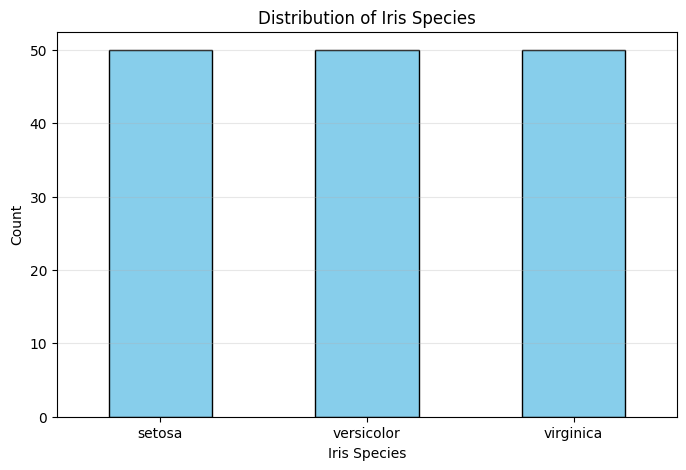


Summary statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  


In [4]:
# Exercise 1: Exploratory Data Analysis
from sklearn.datasets import load_iris

# Load the Iris dataset
iris = load_iris()

# Convert to Pandas DataFrame
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

# Create df with species column - map numeric target to species names
df = X.copy()
df['species'] = y.map({i: name for i, name in enumerate(iris.target_names)})

# Get shape and class counts
shape = df.shape
class_counts = df['species'].value_counts().sort_index()

# Display shape
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"df shape: {shape}")

# Display first few rows
print("\nFirst 5 rows of X:")
print(X.head())

# Show class distribution
print("\nClass distribution:")
print(y.value_counts().sort_index())

# Bar plot
plt.figure(figsize=(8, 5))
y.value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black')
plt.xlabel('Iris Species')
plt.ylabel('Count')
plt.title('Distribution of Iris Species')
plt.xticks(rotation=0, ticks=range(3), labels=iris.target_names)
plt.grid(axis='y', alpha=0.3)
plt.show()

# Summary statistics
print("\nSummary statistics:")
print(X.describe())

In [5]:
### BEGIN TESTS
assert shape == (150, 5)
assert set(df["species"].unique()) == {"setosa", "versicolor", "virginica"}
assert class_counts.sum() == 150
assert df.iloc[0, 0] == iris.data[0, 0]
assert "sepal length (cm)" in df.columns
### END TESTS

### Questions
1. How many classes do we have in the Iris dataset?  
2. Are the classes balanced? How can you tell?  
3. What type of features do we have in this dataset (continuous, ordinal, or categorical)?  

## Exercise 2: Train/Test Split with Stratify

Before we train models, we need to split the dataset into a **training set** (used to fit the model) and a **test set** (used to evaluate performance).  

In classification, it’s important to keep the **class proportions the same** in both sets.  
We achieve this by using **stratification**. Without it, some classes might be underrepresented or missing in the test set.

#### Your tasks:
- Split the data into **80% training** and **20% testing**.  
- Use `train_test_split` with the parameter `stratify=y`.  
- Set `random_state=42` for reproducibility.  
- Store the results in variables: `X_train`, `X_test`, `y_train`, `y_test`.  
- Also compute the **class counts** in both splits and store them in variables:  
  - `train_counts` for the training set  
  - `test_counts` for the test set

<details>
    <summary><strong>Click here for a hint!</strong></summary>
    <ul>
      <li> Import <code>train_test_split</code> from <code>sklearn.model_selection</code>. </li>
      <li> Use <code>test_size=0.2</code> for 20% test data. </li>
      <li> Use <code>stratify=y</code> to keep the class balance. </li>
    </ul>
</details>

In [6]:
# Exercise 2: Train/Test Split with Stratification
from sklearn.model_selection import train_test_split

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Print shapes
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

# Compute class counts
train_counts = y_train.value_counts().sort_index()
test_counts = y_test.value_counts().sort_index()

print("\nTrain set class distribution:")
print(train_counts)

print("\nTest set class distribution:")
print(test_counts)

print("\nStratification verification (proportions):")
print(f"Train proportions: {(train_counts / train_counts.sum()).round(3).to_dict()}")
print(f"Test proportions: {(test_counts / test_counts.sum()).round(3).to_dict()}")

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)

Train set class distribution:
0    40
1    40
2    40
Name: count, dtype: int64

Test set class distribution:
0    10
1    10
2    10
Name: count, dtype: int64

Stratification verification (proportions):
Train proportions: {0: 0.333, 1: 0.333, 2: 0.333}
Test proportions: {0: 0.333, 1: 0.333, 2: 0.333}


In [22]:
### BEGIN TESTS
assert X_train.shape[0] == 120
assert X_test.shape[0] == 30
assert set(y_train.unique()) == {0, 1, 2}
assert all(train_counts / train_counts.sum() == test_counts / test_counts.sum())

assert X_train.shape[1] == 4
assert len(y_test) == 30
### END TESTS

### Questions
1. Why do we use **stratify** when splitting the dataset for classification?  
2. What could happen if we split without stratification?  

## Exercise 3: Logistic Regression

Logistic Regression can handle multiclass classification in two ways:  

- **Multinomial (Softmax)**: Learns a single model that directly estimates probabilities across all classes.  

- **One-vs-Rest (OvR)**: Fits one binary classifier per class (class *i* vs all others).  

⚖️ **Scaling**: Logistic Regression relies on optimization. Features with different scales can affect convergence.  
We recommend using **StandardScaler** for both approaches.

#### Your tasks:
1. Scale the training and test sets using `StandardScaler`.  
2. Fit **multinomial Logistic Regression** on the training set.  
3. Fit **OvR Logistic Regression** using `OneVsRestClassifier` on the same training set.  
4. Predict on the test set for both models.  
5. Compute **classification report** for both approaches.  

<details>
  <summary><strong>Click here for a hint!</strong></summary>
<ul>
  <li>Use <code>StandardScaler</code> to scale your features.</li>
  <li>For multinomial: use <code>LogisticRegression(solver="lbfgs")</code> (multinomial is default).</li>
  <li>For OvR: wrap LogisticRegression with <code>OneVsRestClassifier</code> from <code>sklearn.multiclass</code>.</li>
  <li>Use <code>classification_report</code> from <code>sklearn.metrics</code>.</li>
  <li>Apply <code>fit</code> on training data and <code>predict</code> on test set.</li>
</ul>
</details>

In [7]:
# Exercise 3: Logistic Regression (Multinomial & One-vs-Rest)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report, accuracy_score

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression - Multinomial (softmax)
lr_multi = LogisticRegression(solver='lbfgs', max_iter=200, random_state=42)
lr_multi.fit(X_train_scaled, y_train)
y_pred_lr_multi = lr_multi.predict(X_test_scaled)

print("=" * 70)
print("LOGISTIC REGRESSION - MULTINOMIAL (Softmax)")
print("=" * 70)
print(classification_report(y_test, y_pred_lr_multi, target_names=iris.target_names))
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr_multi):.4f}\n")

# Logistic Regression - One-vs-Rest
lr_ovr = OneVsRestClassifier(LogisticRegression(solver='lbfgs', max_iter=200, random_state=42))
lr_ovr.fit(X_train_scaled, y_train)
y_pred_lr_ovr = lr_ovr.predict(X_test_scaled)

print("=" * 70)
print("LOGISTIC REGRESSION - ONE-VS-REST (OvR)")
print("=" * 70)
print(classification_report(y_test, y_pred_lr_ovr, target_names=iris.target_names))
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr_ovr):.4f}")

LOGISTIC REGRESSION - MULTINOMIAL (Softmax)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

Accuracy: 0.9333

LOGISTIC REGRESSION - ONE-VS-REST (OvR)
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.80      0.84        10
   virginica       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30

Accuracy: 0.9000


In [24]:
# BEGIN TESTS
assert list(np.unique(y_pred_lr_multi)) == [0, 1, 2]
assert list(np.unique(y_pred_lr_ovr)) == [0, 1, 2]
assert isinstance(y_pred_lr_multi, (list, np.ndarray, pd.Series))
assert isinstance(y_pred_lr_ovr, (list, np.ndarray, pd.Series))
# END TESTS

### Questions
1. Why do we need to scale the features before applying Logistic Regression?  
2. What is the main difference between the Multinomial (Softmax) and OvR approaches?  
3. Based on the classification reports, which approach performs better on the Iris dataset?  

## Exercise 4: Naive Bayes

Naive Bayes classifiers are probabilistic models based on **Bayes' theorem** and the **naive assumption** that features are independent given the class.  

### Types of Naive Bayes:
- **GaussianNB**: Assumes features are continuous and normally distributed.  
- **MultinomialNB**: Assumes features are discrete counts (e.g., word frequencies in text classification).  
- **BernoulliNB**: For binary features (0/1).  
- **CategoricalNB**: For categorical features with discrete categories.  

ℹ️ **Note**: GaussianNB is suitable for continuous features like those in the Iris dataset.  
Other types are shown for theoretical knowledge only.

#### Your tasks:
1. Fit **GaussianNB** on the training set.  
2. Predict on the test set.  
3. Compute the **classification report**.  

<details>
  <summary><strong>Click here for a hint!</strong></summary>
  <ul>
  <li>Import <code>GaussianNB</code> from <code>sklearn.naive_bayes</code>.</li>
  <li>Naive Bayes does not require feature scaling.</li>
  <li>Use <code>fit</code> on the training data and <code>predict</code> on the test data.</li>
  <li>Use <code>classification_report</code> from <code>sklearn.metrics</code>.</li>
  </ul>
</details>

In [8]:
# Exercise 4: Gaussian Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Train Gaussian Naive Bayes
gnb = GaussianNB()
gnb.fit(X_train, y_train)  # Note: No scaling needed for Naive Bayes
y_pred_gnb = gnb.predict(X_test)

print("=" * 70)
print("GAUSSIAN NAIVE BAYES")
print("=" * 70)
print(classification_report(y_test, y_pred_gnb, target_names=iris.target_names))
print(f"Accuracy: {accuracy_score(y_test, y_pred_gnb):.4f}")

GAUSSIAN NAIVE BAYES
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Accuracy: 0.9667


In [26]:
# BEGIN TESTS
assert list(np.unique(y_pred_gnb)) == [0, 1, 2]
assert isinstance(y_pred_gnb, (list, np.ndarray, pd.Series))
# END TESTS

### Questions
1. Does GaussianNB require feature scaling? Why or why not?  
2. Based on the classification report, how well does GaussianNB perform on this dataset?  

## Exercise 5: Support Vector Machine

Support Vector Machines (SVC) find the **hyperplane** separating classes with the maximum margin.

### Multiclass Strategy:
- **SVC** uses **one-vs-one (OvO)** internally for multiclass classification.  
- `decision_function_shape='ovr'` can transform OvO outputs into **OvR style** `(n_samples, n_classes)`.

### Kernels:
- **Linear kernel**: For linearly separable data.  
- **RBF (Gaussian) kernel**: Maps data to higher-dimensional space for non-linear separation.

⚖️ **Scaling**: SVC is sensitive to feature scales; always scale features before fitting.

#### Your Tasks:
1. Scale the features using `StandardScaler`.
2. Fit **SVC with linear kernel** on the training set.
3. Fit **SVC with RBF kernel** on the training set.
4. Predict on the test set for both models.
5. Compute the **classification report** for both approaches.

<details>
  <summary><strong>Click here for a hint!</strong></summary>
    <ul>
  <li>Use <code>StandardScaler</code> from <code>sklearn.preprocessing</code> to scale your features.</li>
  <li>Use <code>SVC</code> from <code>sklearn.svm</code> for both linear and RBF kernels.</li>
  <li>Set <code>kernel='linear'</code> for the linear model, <code>kernel='rbf'</code> for the RBF model.</li>
  <li>You can leave <code>decision_function_shape</code> as default for RBF, or set <code>'ovr'</code> for linear if desired.</li>
  <li>Use <code>classification_report</code> from <code>sklearn.metrics</code> to evaluate.</li>
    </ul>
</details>

In [9]:
# Exercise 5: Support Vector Machine (SVM) - Linear and RBF Kernels
from sklearn.svm import SVC

# SVM with Linear Kernel
svc_linear = SVC(kernel='linear', random_state=42)
svc_linear.fit(X_train_scaled, y_train)
y_pred_svc_linear = svc_linear.predict(X_test_scaled)

print("=" * 70)
print("SUPPORT VECTOR MACHINE - LINEAR KERNEL")
print("=" * 70)
print(classification_report(y_test, y_pred_svc_linear, target_names=iris.target_names))
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc_linear):.4f}\n")

# SVM with RBF Kernel
svc_rbf = SVC(kernel='rbf', random_state=42)
svc_rbf.fit(X_train_scaled, y_train)
y_pred_svc_rbf = svc_rbf.predict(X_test_scaled)

print("=" * 70)
print("SUPPORT VECTOR MACHINE - RBF KERNEL")
print("=" * 70)
print(classification_report(y_test, y_pred_svc_rbf, target_names=iris.target_names))
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc_rbf):.4f}")

SUPPORT VECTOR MACHINE - LINEAR KERNEL
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Accuracy: 1.0000

SUPPORT VECTOR MACHINE - RBF KERNEL
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Accuracy: 0.9667


In [28]:
# BEGIN TESTS
assert list(np.unique(y_pred_svc_linear)) == [0, 1, 2]
assert list(np.unique(y_pred_svc_rbf)) == [0, 1, 2]
assert isinstance(y_pred_svc_linear, (list, np.ndarray, pd.Series))
assert isinstance(y_pred_svc_rbf, (list, np.ndarray, pd.Series))
# END TESTS

### Questions
1. How does the choice of kernel (linear vs RBF) affect the decision boundaries?  
2. Explain how SVC handles multiclass classification internally.  
3. Which model performed better on this dataset, and why do you think that is?  

## Exercise 6: Comparing Classifier Performance

In this exercise, you'll compare all the classifiers you've trained so far:

- **Logistic Regression** (OvR and multinomial / softmax)  
- **SVC** (Linear and RBF)  
- **Gaussian Naive Bayes**

#### Your Tasks:
1. For each model, compute the **accuracy**, **precision (weighted)**, **recall (weighted)**, and **F1-score (weighted)** on the test set.
2. Create a **Pandas DataFrame** called `performance_df` with:
   - Rows: model names (`"LR_OvR"`, `"LR_multi`, `"SVC_linear"`, `"SVC_RBF"`, `"GaussianNB"`)  
   - Columns: `accuracy`, `precision`, `recall`, `f1_score`
3. Fill the DataFrame with the computed metrics.
4. Sort the DataFrame by `f1_score` in descending order to easily see the best-performing model.

This summary allows you to **compare all models in one place** and evaluate which performs best on this dataset.

<details>
  <summary><strong>Click here for a hint!</strong></summary>
    <ul>
  <li>Use <code>accuracy_score</code>, <code>precision_score</code>, <code>recall_score</code>, and <code>f1_score</code> from <code>sklearn.metrics</code>.</li>
  <li>Use <code>average='weighted'</code> for multi-class metrics.</li>
  <li>Create a dictionary for each model with metric values, then convert the list of dictionaries to a <code>pd.DataFrame</code>.</li>
  <li>Use <code>sort_values('f1_score', ascending=False)</code> to sort the DataFrame.</li>
    </ul>
</details>

In [12]:
# Exercise 6: Comparing Classifier Performance
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Compute metrics for all models
models_info = {
    "Logistic Regression - OvR": y_pred_lr_ovr,
    "Logistic Regression - Multinomial": y_pred_lr_multi,
    "SVM - Linear": y_pred_svc_linear,
    "SVM - RBF": y_pred_svc_rbf,
    "Gaussian Naive Bayes": y_pred_gnb
}

performance_data = []

for model_name, y_pred in models_info.items():
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    performance_data.append({
        'model': model_name,
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1_score': f1
    })

# Create DataFrame
performance_df = pd.DataFrame(performance_data)

# Sort by F1-score (descending)
performance_df = performance_df.sort_values('f1_score', ascending=False).reset_index(drop=True)

print("=" * 70)
print("CLASSIFIER PERFORMANCE COMPARISON")
print("=" * 70)
print(performance_df.to_string(index=False))

# Best model
best_model = performance_df.iloc[0]
print(f"\nBest Model: {best_model['model']} (F1-Score: {best_model['f1_score']:.4f})")

CLASSIFIER PERFORMANCE COMPARISON
                            model  accuracy  precision   recall  f1_score
                     SVM - Linear  1.000000   1.000000 1.000000  1.000000
             Gaussian Naive Bayes  0.966667   0.969697 0.966667  0.966583
                        SVM - RBF  0.966667   0.969697 0.966667  0.966583
Logistic Regression - Multinomial  0.933333   0.933333 0.933333  0.933333
        Logistic Regression - OvR  0.900000   0.902357 0.900000  0.899749

Best Model: SVM - Linear (F1-Score: 1.0000)


In [13]:
# BEGIN TESTS
assert isinstance(performance_df, pd.DataFrame)
assert all(col in performance_df.columns for col in ["model","accuracy","precision","recall","f1_score"])
assert len(performance_df) == 5
assert (performance_df[["accuracy","precision","recall","f1_score"]].max() <= 1.0).all()
assert (performance_df[["accuracy","precision","recall","f1_score"]].min() >= 0.0).all()
# END TESTS

### Questions   
1. Based on these results, which model would you choose for this dataset and why?

## Exercise 7: Evaluating Probabilities with Log Loss

Instead of only looking at predicted classes, we can evaluate how **good the predicted probabilities** are using **log loss** (cross-entropy).

#### Your Tasks:
1. For the following models:
   - Logistic Regression, multinomial
   - Gaussian Naive Bayes
   - SVC with linear kernel, fitted with `probability=True`
2. Compute the **log loss** on the test set for each model.  
3. Store the results in a dictionary called `logloss_metrics` like this:
```python
logloss_metrics = {
    "lr": ...,
    "gnb": ...,
    "svc": ...
}

<details>
  <summary><strong>Click here for a hint!</strong></summary>
    <ul>
  <li>Use <code>model.predict_proba(X_test_scaled)</code> to get class probabilities.</li>
  <li>Use <code>sklearn.metrics.log_loss(y_test, proba)</code> to compute log loss.</li>
  <li>Lower log loss indicates better probability estimates.</li>
    </ul>
</details>

In [14]:
# Exercise 7: Log Loss (Cross-Entropy) Evaluation
from sklearn.metrics import log_loss

# Get probability predictions
lr_proba = lr_multi.predict_proba(X_test_scaled)
gnb_proba = gnb.predict_proba(X_test)
svc_linear_proba = SVC(kernel='linear', probability=True, random_state=42).fit(X_train_scaled, y_train).predict_proba(X_test_scaled)

# Compute log loss
lr_logloss = log_loss(y_test, lr_proba)
gnb_logloss = log_loss(y_test, gnb_proba)
svc_logloss = log_loss(y_test, svc_linear_proba)

# Store in dictionary
logloss_metrics = {
    "lr": lr_logloss,
    "gnb": gnb_logloss,
    "svc": svc_logloss
}

print("=" * 70)
print("LOG LOSS (Cross-Entropy) EVALUATION")
print("=" * 70)
print(f"Logistic Regression (Multinomial):  {lr_logloss:.4f}")
print(f"Gaussian Naive Bayes:               {gnb_logloss:.4f}")
print(f"SVM (Linear Kernel):                {svc_logloss:.4f}")

print(f"\nBest model (lowest log loss): {min(logloss_metrics, key=logloss_metrics.get).upper()}")
print(f"\nNote: Log Loss measures how well probability estimates are calibrated.")
print(f"Lower is better. Range: [0, ∞) where 0 is perfect.")

LOG LOSS (Cross-Entropy) EVALUATION
Logistic Regression (Multinomial):  0.1740
Gaussian Naive Bayes:               0.1420
SVM (Linear Kernel):                0.1169

Best model (lowest log loss): SVC

Note: Log Loss measures how well probability estimates are calibrated.
Lower is better. Range: [0, ∞) where 0 is perfect.


In [32]:
# BEGIN TESTS
assert isinstance(logloss_metrics, dict)
for v in logloss_metrics.values():
    assert v >= 0
assert set(logloss_metrics.keys()) == {"lr", "gnb", "svc"}
# END TESTS

### Questions
1. Which model has the **lowest log loss**? What does that tell you about its probability estimates?  
2. Can a model have higher accuracy but worse log loss? Explain why.

## Exercise 8: Decision Boundaries

Visualizing decision boundaries helps us **understand how classifiers separate classes** in feature space.

### Feature Mapping
- Feature 0 → Sepal length (cm)  
- Feature 1 → Sepal width (cm)  
- Feature 2 → Petal length (cm)  
- Feature 3 → Petal width (cm)  

#### Your Tasks:
1. Select **two features** from the dataset for visualization (for example, Feature 2 and Feature 3: petal length and petal width).
2. Fit the following models using **only these two features**:
   - Logistic Regression (multinomial / softmax)
   - SVC with RBF kernel
3. Create a **meshgrid** covering the feature ranges.
4. Predict class labels for each point in the meshgrid.
5. Plot the decision boundaries using `plt.contourf` and overlay the **training points**.
6. Compare how each classifier separates the classes visually.

<details>
  <summary><strong>Click here for a hint!</strong></summary>
    <ul>
  <li>Select two features: <code>X_train_scaled[:, [0, 1]]</code> (or any pair).</li>
  <li>Create a meshgrid: <code>np.meshgrid</code> over the feature ranges.</li>
  <li>Use <code>model.predict</code> on the meshgrid points.</li>
  <li>Plot boundaries: <code>plt.contourf(xx, yy, Z, alpha=0.3)</code>.</li>
  <li>Overlay the training points: <code>plt.scatter(...)</code>.</li>
    </ul>
</details>

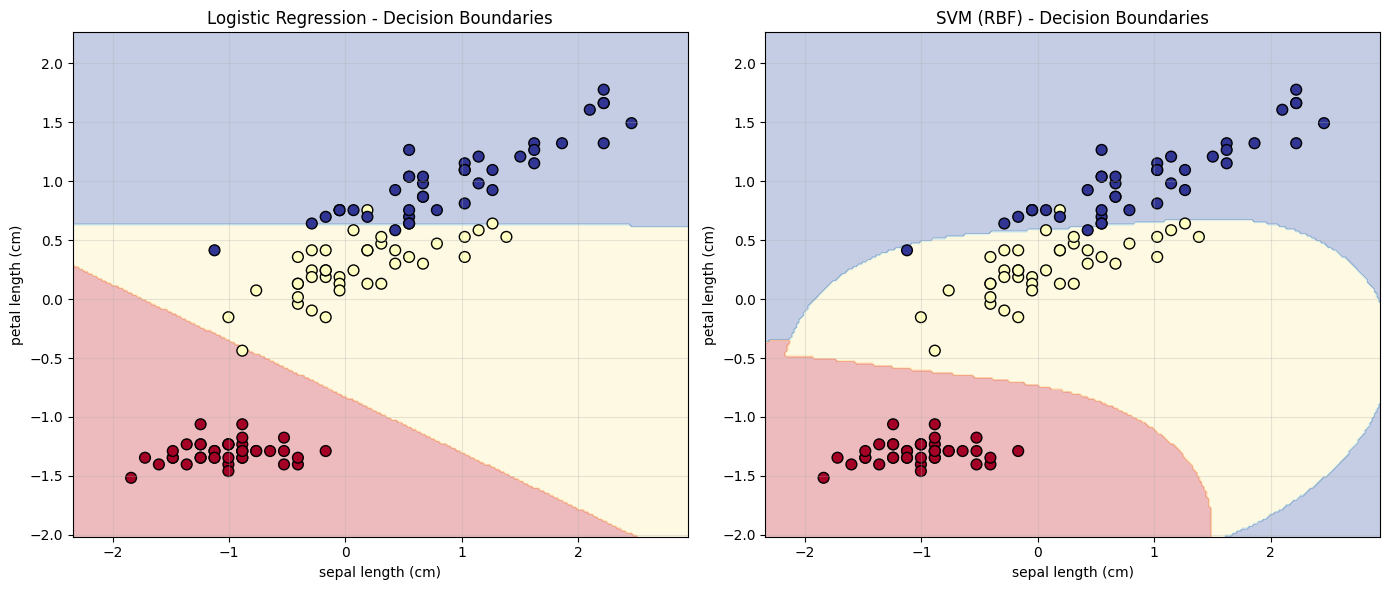

Decision boundary visualization complete!


In [33]:
# Exercise 8: Decision Boundaries Visualization
import numpy as np

# Select 2 features for visualization (sepal length and petal length)
feature_indices = [0, 2]  # sepal length and petal length
X_train_2d = X_train_scaled[:, feature_indices]
X_test_2d = X_test_scaled[:, feature_indices]

# Create meshgrid for visualization
h = 0.02  # step size
x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Train models with 2D features
lr_2d = LogisticRegression(solver='lbfgs', max_iter=200, random_state=42)
lr_2d.fit(X_train_2d, y_train)

svc_2d = SVC(kernel='rbf', random_state=42)
svc_2d.fit(X_train_2d, y_train)

# Predict on meshgrid
Z_lr = lr_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
Z_svc = svc_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Logistic Regression
ax1.contourf(xx, yy, Z_lr, alpha=0.3, cmap='RdYlBu')
scatter1 = ax1.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap='RdYlBu', 
                       edgecolors='k', s=60, label='Training data')
ax1.set_xlabel(iris.feature_names[feature_indices[0]])
ax1.set_ylabel(iris.feature_names[feature_indices[1]])
ax1.set_title('Logistic Regression - Decision Boundaries')
ax1.grid(True, alpha=0.3)

# SVM with RBF
ax2.contourf(xx, yy, Z_svc, alpha=0.3, cmap='RdYlBu')
scatter2 = ax2.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap='RdYlBu', 
                       edgecolors='k', s=60, label='Training data')
ax2.set_xlabel(iris.feature_names[feature_indices[0]])
ax2.set_ylabel(iris.feature_names[feature_indices[1]])
ax2.set_title('SVM (RBF) - Decision Boundaries')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Decision boundary visualization complete!")

In [34]:
### BEGIN TESTS
assert 'xx' in globals() and 'yy' in globals()
assert xx.shape == yy.shape
assert xx.shape[0] > 0 and xx.shape[1] > 0
### END TESTS

### Questions
1. How do the decision boundaries differ between Logistic Regression and Linear SVC?  
2. Which model seems more flexible? Which is more linear?